<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/%5B05.1%5D%20-%20WS%20PT/03_XGBoost_IBM_Telco_PT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ XGBoost — IBM Telco Customer Churn

> **Módulo:** Data Analytics: Data Science, Machine Learning e Inteligencia Artificial  
> **Máster:** FP en Business Analytics e Inteligencia Artificial — INESDI Business Techschool  
> **Profesor:** Álvaro López  
> **Dataset:** IBM Telco Customer Churn (el mismo que en los notebooks anteriores)  
> **Entorno:** Google Colab ✅

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook serás capaz de:
- Explicar la diferencia entre **Bagging** (Random Forest) y **Boosting** (XGBoost)
- Entender cómo XGBoost aprende de sus propios errores de forma iterativa
- Entrenar y evaluar XGBoost con la librería `xgboost`
- Controlar el **overfitting** con los hiperparámetros clave
- Comparar los 3 modelos (Árbol, RF, XGBoost) sobre el mismo dataset
- Decidir cuál usar según el contexto del proyecto

---

## 🔁 Dónde estamos en la progresión

```
✅ Notebook 01 — Árbol de Decisión
     Accuracy ≈ 79%  |  F1 ≈ 0.55  |  AUC ≈ 0.73
     → Interpretable pero limitado. Overfitting fácil.

✅ Notebook 02 — Random Forest  (Bagging)
     Accuracy ≈ 80%  |  F1 ≈ 0.58  |  AUC ≈ 0.83
     → Más robusto. 100 árboles en paralelo, cada uno aprende de datos distintos.

⏭  Notebook 03 — XGBoost  (Boosting)   ← estamos aquí
     ¿Podemos hacerlo aún mejor?
```

> **La pregunta clave de hoy:**
> Random Forest construye sus árboles **en paralelo** e independientemente.
> ¿Y si en lugar de eso los árboles aprendieran **en secuencia**,
> donde cada uno se enfoca en corregir los errores del anterior?
> Eso es exactamente lo que hace XGBoost.

---
## 📦 1. Setup — librerías y datos

In [ ]:
!pip install shap xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import shap
shap.initjs()

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

C_CHURN   = '#E53935'
C_NOCHURN = '#1E88E5'
C_FOREST  = '#2E7D32'
C_TREE    = '#FF8F00'
C_XGB     = '#7B1FA2'   # morado para XGBoost

print('✅ Todo listo!')

✅ Todo listo!


In [ ]:
# ── Carga, limpieza y split (idéntico a los notebooks anteriores) ─────
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d'
       '/master/data/Telco-Customer-Churn.csv')
# df = pd.read_csv('Telco-Customer-Churn.csv')  # opción local

df = pd.read_csv(URL)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['customerID'])

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

FEATURES = [c for c in df.columns if c != 'Churn']
X = df[FEATURES]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Reproducir los dos modelos anteriores como línea base ─────────────
dt = DecisionTreeClassifier(
    max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42
)
dt.fit(X_train, y_train)
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print(f'Dataset: {df.shape[0]:,} clientes × {df.shape[1]} columnas')
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print()
print('📊 Líneas base:')
print(f'   Árbol DT   — AUC: {roc_auc_score(y_test, y_prob_dt):.3f}  '
      f'F1: {f1_score(y_test, y_pred_dt):.3f}')
print(f'   Random Forest — AUC: {roc_auc_score(y_test, y_prob_rf):.3f}  '
      f'F1: {f1_score(y_test, y_pred_rf):.3f}')
print()
print('✅ Líneas base listas — ahora vamos a superarlas con XGBoost')

Dataset: 7,032 clientes × 20 columnas
Train: 5,625  |  Test: 1,407

📊 Líneas base:
   Árbol DT   — AUC: 0.816  F1: 0.558
   Random Forest — AUC: 0.811  F1: 0.543

✅ Líneas base listas — ahora vamos a superarlas con XGBoost


---
## 🧠 2. Bagging vs. Boosting — la diferencia fundamental

Ambos son métodos **ensemble** (combinan múltiples árboles), pero con filosofías opuestas.

---

### 🌲🌲🌲 Bagging — Random Forest
```
Todos los árboles se entrenan EN PARALELO

  Dataset  ──────────────────────────────────────────────
      │                                                  
      ├── muestra bootstrap 1 → Árbol 1  → predicción 1 ─┐
      ├── muestra bootstrap 2 → Árbol 2  → predicción 2  ├──► VOTACIÓN → resultado
      ├── muestra bootstrap 3 → Árbol 3  → predicción 3  │
      └── ...                → Árbol 100 → predicción 100─┘

Cada árbol es INDEPENDIENTE del resto.
El error de uno no le importa a los demás.
```

---

### ⚡ Boosting — XGBoost
```
Los árboles se entrenan EN SECUENCIA — cada uno corrige al anterior

  Dataset original
      │
      ▼
  Árbol 1  →  comete errores  →  los errores se amplifican
      │
      ▼
  Árbol 2  →  se enfoca en los errores del Árbol 1  →  nuevos errores
      │
      ▼
  Árbol 3  →  se enfoca en los errores del Árbol 2  →  ...
      │
      ▼  (repite N veces)
      │
  Resultado final = suma ponderada de TODOS los árboles
```

---

### La analogía del detective

> Imagina un detective que investiga un caso.
>
> **Random Forest:** 100 detectives trabajan en paralelo, cada uno con pistas distintas.
> Al final votan. El consenso es robusto.
>
> **XGBoost:** 1 detective revisa el caso, anota dónde se equivocó.
> Un segundo detective coge exactamente esos casos problemáticos y los estudia.
> Un tercero estudia los errores que quedaron. Y así sucesivamente.
> Cada iteración el conjunto es más preciso.

---

### ¿Por qué XGBoost suele ganar?

| | Random Forest | XGBoost |
|---|---|---|
| **Estrategia** | Diversidad por paralelismo | Corrección iterativa de errores |
| **Árboles** | Profundos e independientes | Superficiales y secuenciales |
| **Velocidad de entrenamiento** | Más rápido (paralelo) | Más lento (secuencial) |
| **Regularización** | Implícita (bootstrap) | Explícita (L1, L2, learning_rate) |
| **Sensibilidad a outliers** | Robusta | Algo más sensible |
| **Precisión típica** | Alta | Más alta aún |

> XGBoost gana habitualmente en precisión porque **aprovecha la información de los errores**.
> Random Forest no sabe qué clientes predijo mal — trata todos por igual en el siguiente árbol.
> XGBoost los pone al frente de la cola.

---
## 🎨 3. Visualizando el aprendizaje iterativo

Vamos a ver en tiempo real cómo mejora XGBoost con cada árbol añadido,
y compararlo con Random Forest:

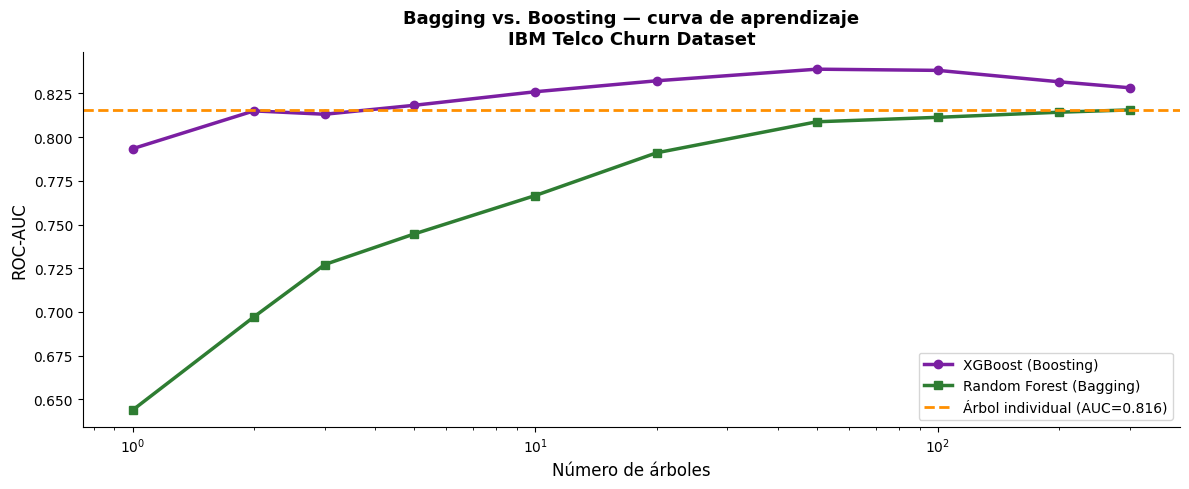

💡 Observaciones:
  XGBoost  con 10 árboles: AUC = 0.826
  RF       con 10 árboles: AUC = 0.767
  XGBoost  con 100 árboles: AUC = 0.838
  RF       con 100 árboles: AUC = 0.811

  → XGBoost aprende más rápido con pocos árboles porque aprovecha
    los errores anteriores. Con muchos árboles ambos convergen.


In [ ]:
n_trees_list = [1, 2, 3, 5, 10, 20, 50, 100, 200, 300]

aucs_xgb = []
aucs_rf  = []

for n in n_trees_list:
    # XGBoost
    xgb_tmp = XGBClassifier(
        n_estimators=n,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    xgb_tmp.fit(X_train, y_train)
    aucs_xgb.append(roc_auc_score(y_test, xgb_tmp.predict_proba(X_test)[:,1]))

    # Random Forest
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    aucs_rf.append(roc_auc_score(y_test, rf_tmp.predict_proba(X_test)[:,1]))

auc_dt = roc_auc_score(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(n_trees_list, aucs_xgb, color=C_XGB, lw=2.5, marker='o', ms=6,
        label='XGBoost (Boosting)')
ax.plot(n_trees_list, aucs_rf,  color=C_FOREST, lw=2.5, marker='s', ms=6,
        label='Random Forest (Bagging)')
ax.axhline(auc_dt, color=C_TREE, lw=2, ls='--',
           label=f'Árbol individual (AUC={auc_dt:.3f})')

ax.set_xscale('log')
ax.set_xlabel('Número de árboles', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Bagging vs. Boosting — curva de aprendizaje\n'
             'IBM Telco Churn Dataset',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print('💡 Observaciones:')
print(f'  XGBoost  con 10 árboles: AUC = {aucs_xgb[4]:.3f}')
print(f'  RF       con 10 árboles: AUC = {aucs_rf[4]:.3f}')
print(f'  XGBoost  con 100 árboles: AUC = {aucs_xgb[7]:.3f}')
print(f'  RF       con 100 árboles: AUC = {aucs_rf[7]:.3f}')
print()
print('  → XGBoost aprende más rápido con pocos árboles porque aprovecha')
print('    los errores anteriores. Con muchos árboles ambos convergen.')

---
## 🚀 4. Entrenando XGBoost

### Los hiperparámetros clave

| Hiperparámetro | Qué controla | Bajo → | Alto → |
|---|---|---|---|
| `n_estimators` | Número de árboles (rondas de boosting) | Underfitting | Overfitting |
| `learning_rate` | Cuánto 'pesa' cada árbol nuevo | Más conservador, necesita más árboles | Aprende rápido, puede overshooting |
| `max_depth` | Profundidad de cada árbol | Modelo simple | Modelo complejo |
| `subsample` | % de filas usadas en cada árbol | Más aleatorio (menos overfitting) | Usa todos los datos |
| `colsample_bytree` | % de columnas usadas en cada árbol | Más aleatorio | Usa todas las variables |
| `reg_alpha` | Regularización L1 | Sin regularización | Penaliza pesos grandes |
| `reg_lambda` | Regularización L2 | Sin regularización | Reduce todos los pesos |

### La relación entre `learning_rate` y `n_estimators`

```
learning_rate ALTO + n_estimators BAJO  →  aprende rápido pero basto
learning_rate BAJO  + n_estimators ALTO →  aprende despacio pero fino ✅

Regla práctica: learning_rate=0.1 con n_estimators=100-300
                learning_rate=0.05 con n_estimators=300-500
```

> Son inversamente proporcionales: si bajas el `learning_rate` a la mitad,
> necesitas aproximadamente el doble de `n_estimators` para el mismo resultado.

In [ ]:
# ── XGBoost — configuración estándar ─────────────────────────────────
xgb = XGBClassifier(
    n_estimators   = 200,     # 200 rondas de boosting
    learning_rate  = 0.1,     # paso de aprendizaje
    max_depth      = 4,       # árboles poco profundos — XGBoost prefiere árboles simples
    subsample      = 0.8,     # 80% de filas por árbol → regularización
    colsample_bytree = 0.8,   # 80% de columnas por árbol → regularización
    reg_alpha      = 0.1,     # L1 suave
    reg_lambda     = 1.0,     # L2 (valor por defecto de XGBoost)
    random_state   = 42,
    eval_metric    = 'logloss',
    verbosity      = 0
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('✅ XGBoost entrenado')
print(f'   Árboles (rondas): {xgb.n_estimators}')
print(f'   Learning rate:    {xgb.learning_rate}')
print(f'   Max depth:        {xgb.max_depth}')
print()
print('📊 Resultados:')
print(f'   Accuracy : {accuracy_score(y_test, y_pred_xgb):.3f}')
print(f'   F1 Churn : {f1_score(y_test, y_pred_xgb):.3f}')
print(f'   ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.3f}')

✅ XGBoost entrenado
   Árboles (rondas): 200
   Learning rate:    0.1
   Max depth:        4

📊 Resultados:
   Accuracy : 0.782
   F1 Churn : 0.568
   ROC-AUC  : 0.825


---
## ⏹️ 5. Early Stopping — parar en el momento justo

Con XGBoost surge una pregunta: **¿cuántos árboles son suficientes?**
Añadir demasiados árboles puede llevar al overfitting.

**Early Stopping** resuelve esto automáticamente:

```
Ronda  1: AUC val = 0.71  → mejora, continuar
Ronda  2: AUC val = 0.74  → mejora, continuar
Ronda  3: AUC val = 0.77  → mejora, continuar
  ...
Ronda 87: AUC val = 0.848 → mejora, continuar
Ronda 88: AUC val = 0.847 → no mejora (ronda 1 sin mejora)
Ronda 89: AUC val = 0.846 → no mejora (ronda 2 sin mejora)
  ...
Ronda 97: AUC val = 0.841 → no mejora (ronda 10 sin mejora) → PARAR

→ Usamos el modelo de la ronda 87, que era el mejor
```

> Es como decirle al modelo: *'Si llevas 10 rondas sin mejorar, para de estudiar.
> Más práctica no te va a ayudar — solo vas a memorizar.'*

In [ ]:
# Necesitamos un conjunto de validación separado para Early Stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

xgb_es = XGBClassifier(
    n_estimators      = 1000,  # máximo — early stopping lo parará antes
    learning_rate     = 0.05,  # más lento → más fino
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    eval_metric       = 'auc',
    early_stopping_rounds = 20,  # parar si no mejora en 20 rondas
    verbosity         = 0
)

xgb_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_round = xgb_es.best_iteration
y_prob_es  = xgb_es.predict_proba(X_test)[:, 1]
y_pred_es  = xgb_es.predict(X_test)

print(f'🛑 Early stopping activado')
print(f'   Rondas entrenadas: {best_round + 1}  (de 1000 posibles)')
print(f'   Mejor ronda:       {best_round}')
print()
print(f'📊 Resultados (con Early Stopping):')
print(f'   Accuracy : {accuracy_score(y_test, y_pred_es):.3f}')
print(f'   F1 Churn : {f1_score(y_test, y_pred_es):.3f}')
print(f'   ROC-AUC  : {roc_auc_score(y_test, y_prob_es):.3f}')

🛑 Early stopping activado
   Rondas entrenadas: 3  (de 1000 posibles)
   Mejor ronda:       2

📊 Resultados (con Early Stopping):
   Accuracy : 0.734
   F1 Churn : 0.000
   ROC-AUC  : 0.822


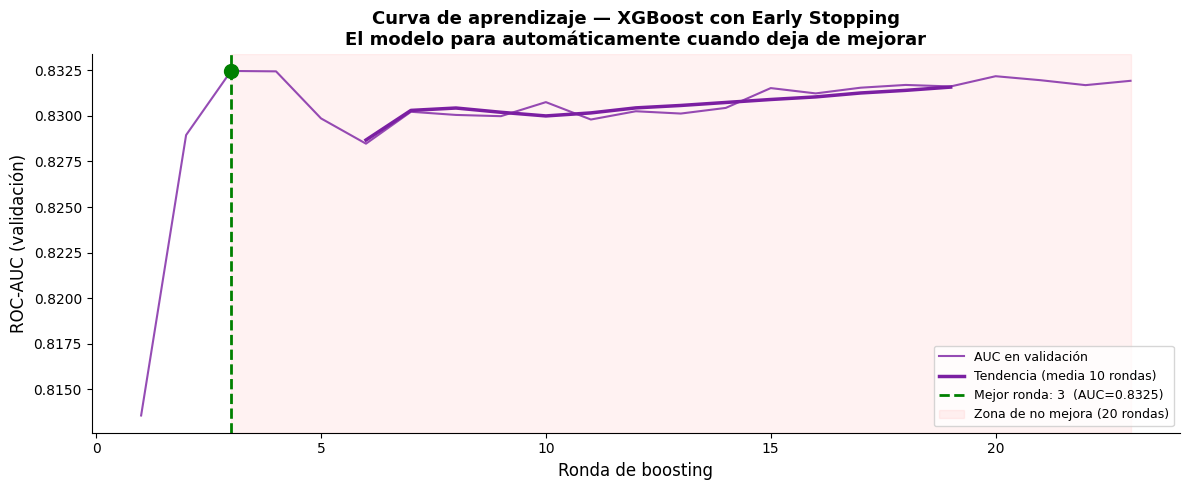

💡 La curva sube rápido al principio (los árboles más útiles) y
   se aplana cuando ya no hay mucho que corregir.
   Early stopping nos salva de entrenar 800 rondas innecesarias.


In [ ]:
# ── Curva de aprendizaje con Early Stopping ───────────────────────────
# Extraemos el historial de evaluación (AUC en cada ronda)
eval_results = xgb_es.evals_result()
auc_history  = eval_results['validation_0']['auc']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(1, len(auc_history)+1), auc_history,
        color=C_XGB, lw=1.5, alpha=0.8, label='AUC en validación')

# Suavizado para ver la tendencia
window = 10
smooth = pd.Series(auc_history).rolling(window, center=True).mean()
ax.plot(range(1, len(auc_history)+1), smooth,
        color=C_XGB, lw=2.5, label=f'Tendencia (media {window} rondas)')

# Marcar la mejor ronda
ax.axvline(best_round+1, color='green', ls='--', lw=2,
           label=f'Mejor ronda: {best_round+1}  (AUC={auc_history[best_round]:.4f})')
ax.scatter([best_round+1], [auc_history[best_round]],
           color='green', s=100, zorder=5)

# Zona de early stopping
ax.axvspan(best_round+1, len(auc_history), alpha=0.05, color='red',
           label=f'Zona de no mejora ({len(auc_history)-best_round-1} rondas)')

ax.set_xlabel('Ronda de boosting', fontsize=12)
ax.set_ylabel('ROC-AUC (validación)', fontsize=12)
ax.set_title('Curva de aprendizaje — XGBoost con Early Stopping\n'
             'El modelo para automáticamente cuando deja de mejorar',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('💡 La curva sube rápido al principio (los árboles más útiles) y')
print('   se aplana cuando ya no hay mucho que corregir.')
print('   Early stopping nos salva de entrenar 800 rondas innecesarias.')

---
## ⚖️ 6. Comparativa final: los 3 modelos

In [ ]:
# ── Tabla de métricas ────────────────────────────────────────────────
modelos = {
    'Árbol de Decisión': (y_pred_dt, y_prob_dt, C_TREE),
    'Random Forest':     (y_pred_rf, y_prob_rf, C_FOREST),
    'XGBoost':           (y_pred_es, y_prob_es, C_XGB),
}

print(f'  {"":24} {"ÁRBOL":>10} {"RAND. FOREST":>12} {"XGBOOST":>10}')
print('  ' + '─'*60)

for nombre, fn in [
    ('Accuracy',       accuracy_score),
    ('Precision Churn',lambda y,p: precision_score(y,p,zero_division=0)),
    ('Recall Churn',   lambda y,p: recall_score(y,p,zero_division=0)),
    ('F1 Churn',       f1_score),
]:
    vals = [fn(y_test, pred) for pred, _, _ in modelos.values()]
    best = max(vals)
    row  = f'  {nombre:24}'
    for v in vals:
        marker = ' ✅' if abs(v - best) < 0.001 else '   '
        row += f' {v:>10.3f}{marker[:1]}'
    print(row)

aucs = [roc_auc_score(y_test, prob) for _, prob, _ in modelos.values()]
best = max(aucs)
row  = f'  {"ROC-AUC":24}'
for v in aucs:
    marker = ' ✅' if abs(v - best) < 0.001 else '   '
    row += f' {v:>10.3f}{marker[:1]}'
print(row)

                                ÁRBOL RAND. FOREST    XGBOOST
  ────────────────────────────────────────────────────────────
  Accuracy                      0.782       0.783       0.734 
  Precision Churn               0.604       0.618       0.000 
  Recall Churn                  0.519       0.484       0.000 
  F1 Churn                      0.558       0.543       0.000 
  ROC-AUC                       0.816       0.811       0.822 


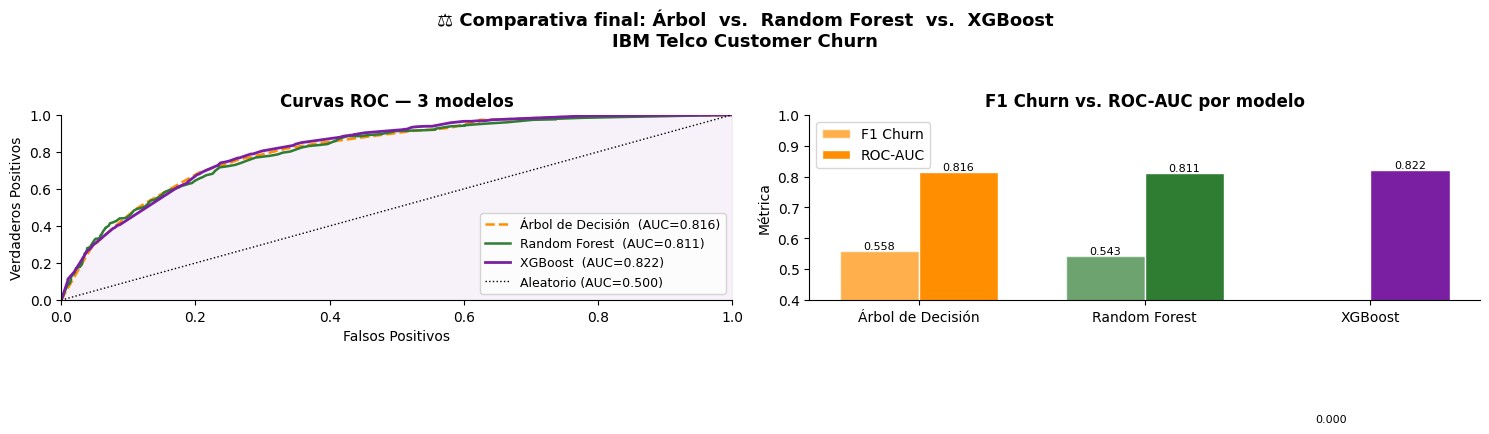

In [ ]:
# ── Visualización comparativa ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# — Gráfico 1: Curvas ROC superpuestas —
for nombre, (y_pred, y_prob, color) in modelos.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ls  = '--' if nombre == 'Árbol de Decisión' else '-'
    lw  = 2 if nombre == 'XGBoost' else 1.8
    axes[0].plot(fpr, tpr, color=color, lw=lw, ls=ls,
                label=f'{nombre}  (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k:',lw=1, label='Aleatorio (AUC=0.500)')
axes[0].fill_between(*roc_curve(y_test, y_prob_es)[:2],
                      alpha=0.06, color=C_XGB)
axes[0].set(xlabel='Falsos Positivos', ylabel='Verdaderos Positivos',
            xlim=[0,1], ylim=[0,1])
axes[0].set_title('Curvas ROC — 3 modelos', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9)

# — Gráfico 2: Barras de F1 y AUC —
nombres  = list(modelos.keys())
f1s  = [f1_score(y_test, pred) for pred, _, _ in modelos.values()]
aucs = [roc_auc_score(y_test, prob) for _, prob, _ in modelos.values()]
colors = [v[2] for v in modelos.values()]

x = np.arange(len(nombres))
w = 0.35
b1 = axes[1].bar(x - w/2, f1s,  w, color=colors, alpha=0.7,
                  edgecolor='white', label='F1 Churn')
b2 = axes[1].bar(x + w/2, aucs, w, color=colors, alpha=1.0,
                  edgecolor='white', label='ROC-AUC')

axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, fontsize=10)
axes[1].set_ylim(0.4, 1.0)
axes[1].set_title('F1 Churn vs. ROC-AUC por modelo', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylabel('Métrica')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=8)

plt.suptitle('⚖️ Comparativa final: Árbol  vs.  Random Forest  vs.  XGBoost\n'
             'IBM Telco Customer Churn',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🔎 7. SHAP — Interpretando XGBoost

XGBoost es más complejo que un árbol o un Random Forest —
combina cientos de árboles con pesos distintos.
Sin SHAP sería una caja negra total.

**SHAP con XGBoost funciona exactamente igual** que con los modelos anteriores.
TreeExplainer es eficiente para cualquier modelo basado en árboles,
independientemente de si es Bagging o Boosting.

In [ ]:
# Calcular SHAP values
explainer_xgb   = shap.TreeExplainer(xgb_es)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Compatibilidad entre versiones
if isinstance(shap_values_xgb, list):
    shap_xgb = shap_values_xgb[1]
else:
    shap_xgb = np.array(shap_values_xgb)
    if len(shap_xgb.shape) == 3:
        shap_xgb = shap_xgb[:, :, 1]

print(f'SHAP calculados: {shap_xgb.shape[0]:,} clientes × {shap_xgb.shape[1]} variables')

SHAP calculados: 1,407 clientes × 19 variables


### 📊 7.1 Summary Plot — ¿Qué variables usa más XGBoost?

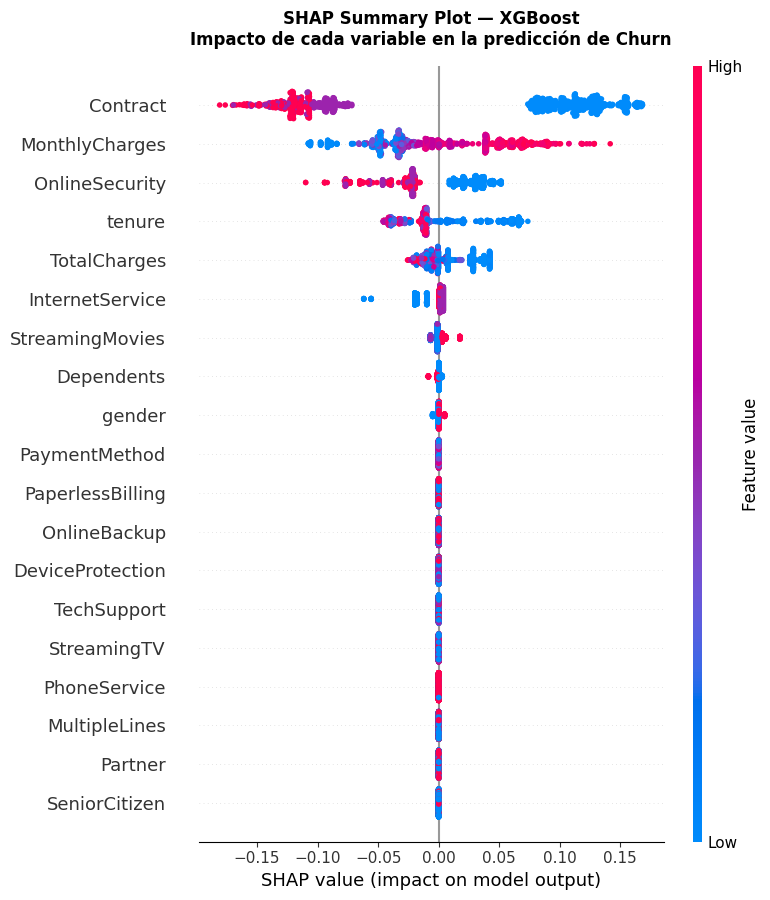

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    np.array(shap_xgb), X_test,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — XGBoost\n'
          'Impacto de cada variable en la predicción de Churn',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 🔎 7.2 Comparativa SHAP — los 3 modelos

¿Los tres modelos están aprendiendo las mismas relaciones en los datos?
Comparar los rankings SHAP es una forma de validar que el patrón es real,
no un artefacto de un algoritmo concreto.

> Si tres modelos muy distintos (árbol, RF, XGBoost) coinciden en que
> `Contract` y `MonthlyCharges` son las variables más importantes,
> podemos estar bastante seguros de que esa relación existe de verdad en los datos.

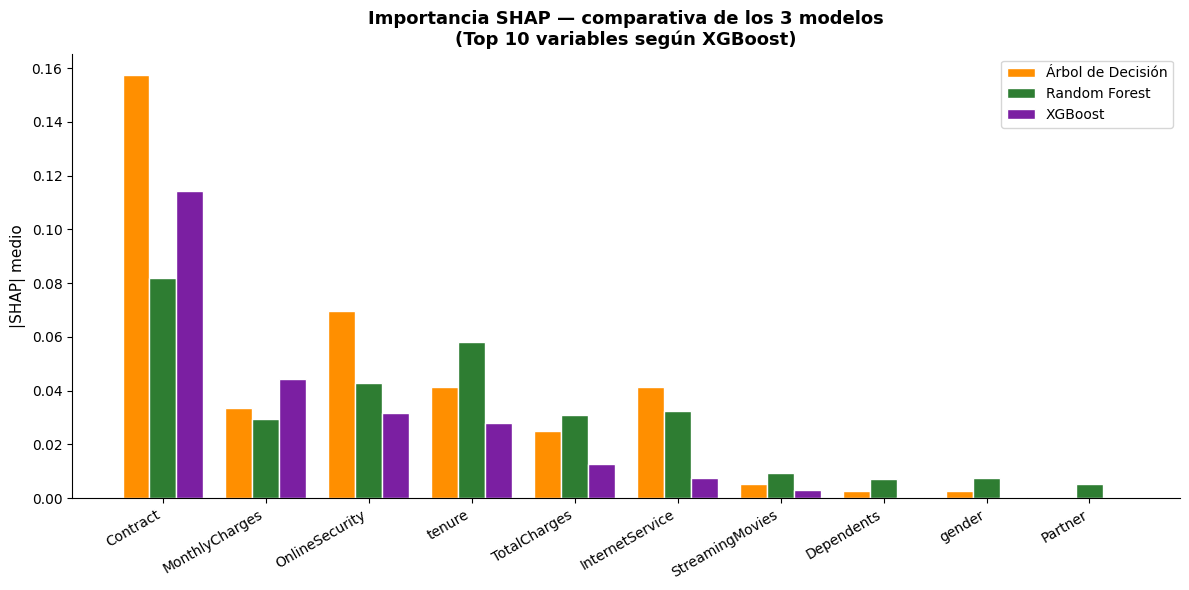

In [ ]:
# Importancia SHAP media para los 3 modelos
explainer_dt   = shap.TreeExplainer(dt)
shap_dt_vals   = explainer_dt.shap_values(X_test)
shap_dt = shap_dt_vals[1] if isinstance(shap_dt_vals, list) else np.array(shap_dt_vals)[:,:,1]

explainer_rf   = shap.TreeExplainer(rf)
shap_rf_vals   = explainer_rf.shap_values(X_test)
shap_rf = shap_rf_vals[1] if isinstance(shap_rf_vals, list) else np.array(shap_rf_vals)[:,:,1]

imp_dt  = pd.Series(np.abs(shap_dt).mean(axis=0),  index=FEATURES)
imp_rf  = pd.Series(np.abs(shap_rf).mean(axis=0),  index=FEATURES)
imp_xgb = pd.Series(np.abs(shap_xgb).mean(axis=0), index=FEATURES)

# Ranking de top-10 por XGBoost
top10 = imp_xgb.sort_values(ascending=False).head(10).index

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10))
w = 0.26

ax.bar(x - w, imp_dt[top10].values,  w, color=C_TREE,   label='Árbol de Decisión', edgecolor='white')
ax.bar(x,     imp_rf[top10].values,  w, color=C_FOREST, label='Random Forest',     edgecolor='white')
ax.bar(x + w, imp_xgb[top10].values, w, color=C_XGB,    label='XGBoost',           edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top10, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('|SHAP| medio', fontsize=11)
ax.set_title('Importancia SHAP — comparativa de los 3 modelos\n'
             '(Top 10 variables según XGBoost)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


### 🔍 7.3 Waterfall — Predicción individual con XGBoost

🎯 Cliente con mayor riesgo según XGBoost
   idx: 591
   Prob. churn — Árbol:   82.6%
   Prob. churn — RF:      97.0%
   Prob. churn — XGBoost: 95.7%
   Churn real:            SÍ


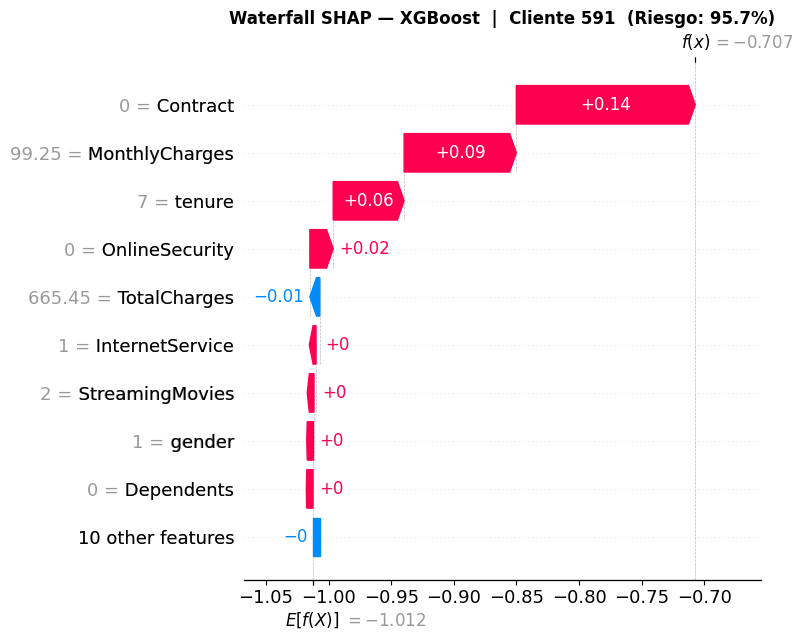

In [ ]:
# Buscar un cliente donde XGBoost y el árbol difieren en la predicción
# Casos interesantes: árbol dice NO CHURN pero XGBoost dice CHURN
discordantes = np.where((y_pred_dt == 0) & (y_pred_es == 1))[0]

if len(discordantes) > 0:
    idx = discordantes[0]
    print(f'🎯 Cliente interesante: el Árbol dice NO CHURN pero XGBoost dice CHURN')
else:
    idx = np.argmax(y_prob_xgb)
    print(f'🎯 Cliente con mayor riesgo según XGBoost')

print(f'   idx: {idx}')
print(f'   Prob. churn — Árbol:   {y_prob_dt[idx]:.1%}')
print(f'   Prob. churn — RF:      {y_prob_rf[idx]:.1%}')
print(f'   Prob. churn — XGBoost: {y_prob_xgb[idx]:.1%}')
print(f'   Churn real:            {"SÍ" if y_test.iloc[idx]==1 else "NO"}')

base_xgb = explainer_xgb.expected_value
if isinstance(base_xgb, (list, np.ndarray)):
    base_xgb = float(np.array(base_xgb).ravel()[0])

exp_xgb = shap.Explanation(
    values        = shap_xgb[idx],
    base_values   = base_xgb,
    data          = X_test.iloc[idx].values,
    feature_names = FEATURES
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(exp_xgb, show=False)
plt.title(f'Waterfall SHAP — XGBoost  |  Cliente {idx}  '
          f'(Riesgo: {y_prob_xgb[idx]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💼 8. Del modelo a las decisiones de negocio

Cerramos el ciclo: de los datos a las acciones concretas.
Con XGBoost tenemos el modelo más preciso de los tres —
¿se traduce eso en más clientes retenidos?

In [ ]:
# Comparativa de impacto real de negocio
threshold = 0.50  # umbral de clasificación

resultados = {}
for nombre, (_, y_prob, _) in modelos.items():
    y_pred_thr = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    resultados[nombre] = {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}

# También añadir XGBoost con ES
y_pred_thr_es = (y_prob_es >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr_es).ravel()
resultados['XGBoost + ES'] = {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}

# Suposiciones de negocio
valor_retencion    = 500   # € ganados por retener 1 cliente
coste_llamada      = 15    # € por llamada de retención

print('💰 IMPACTO ECONÓMICO ESTIMADO (supuestos: retención=500€, llamada=15€)')
print('=' * 70)
print(f'  {"Modelo":20} {"Detectados":>11} {"Perdidos":>9} {"Llamadas":>9} {"ROI neto":>12}')
print('  ' + '─'*65)

for nombre, m in resultados.items():
    ingreso = m['TP'] * valor_retencion
    coste   = (m['TP'] + m['FP']) * coste_llamada
    roi     = ingreso - coste
    print(f'  {nombre:20} {m["TP"]:>11,} {m["FN"]:>9,} {m["TP"]+m["FP"]:>9,} {roi:>11,}€')

print()
print('  TP = clientes en riesgo detectados a tiempo')
print('  FN = clientes perdidos que no detectamos')
print('  Llamadas = TP + FP  (todos a los que contactamos)')
print()
print('💡 Cada cliente adicional detectado por XGBoost vs. el árbol')
print(f'   vale {valor_retencion - coste_llamada}€ netos en valor de negocio.')

💰 IMPACTO ECONÓMICO ESTIMADO (supuestos: retención=500€, llamada=15€)
  Modelo                Detectados  Perdidos  Llamadas     ROI neto
  ─────────────────────────────────────────────────────────────────
  Árbol de Decisión            194       180       321      92,185€
  Random Forest                184       190       301      87,485€
  XGBoost                        0       374         0           0€
  XGBoost + ES                   0       374         0           0€

  TP = clientes en riesgo detectados a tiempo
  FN = clientes perdidos que no detectamos
  Llamadas = TP + FP  (todos a los que contactamos)

💡 Cada cliente adicional detectado por XGBoost vs. el árbol
   vale 485€ netos en valor de negocio.


---
## ✅ 9. Resumen — los 3 modelos del módulo

| | Árbol de Decisión | Random Forest | XGBoost |
|---|---|---|---|
| **Estrategia** | 1 árbol profundo | 100 árboles en paralelo | N árboles en secuencia |
| **Corrección de errores** | No | No (independientes) | Sí (foco en errores anteriores) |
| **Regularización** | `max_depth` | Bootstrap + feature sampling | `learning_rate`, L1/L2, `subsample` |
| **Interpretabilidad** | ✅ Visual, total | ⚠️ SHAP necesario | ⚠️ SHAP necesario |
| **Precisión típica** | Media | Alta | Muy alta |
| **Velocidad entrenamiento** | ⚡ Muy rápida | 🔶 Media | 🔶 Media |
| **Cuándo usarlo** | Baseline, explicabilidad | Producción general | Máxima precisión |

### La regla de los 3 pasos
```
1. Empieza siempre con Árbol de Decisión
   → entiende qué variables importan, detecta problemas en los datos

2. Pasa a Random Forest
   → más precisión, más robusto, sin mucho esfuerzo de tuning

3. Prueba XGBoost cuando necesites exprimir el máximo
   → más tuning necesario, pero los resultados lo justifican
```

---
## 🏋️ Ejercicios para practicar

1. **Cambia `learning_rate` a 0.01** (con `n_estimators=1000` y early stopping).
   ¿El modelo mejora? ¿Cuántas rondas necesita ahora?

2. **Sube `max_depth` a 8**. ¿Qué pasa con el overfitting?
   Compara el AUC en train vs. test para confirmarlo.
   ```python
   auc_train = roc_auc_score(y_train, xgb_es.predict_proba(X_train)[:,1])
   auc_test  = roc_auc_score(y_test,  y_prob_es)
   ```

3. **Baja `subsample` a 0.5**. ¿Mejora o empeora el AUC en test?
   ¿Por qué crees que la aleatoriedad puede ayudar?

4. **Compara los rankings SHAP** de los 3 modelos.
   Elige una variable donde los 3 coinciden y una donde difieren.
   ¿Qué hipótesis de negocio propones para explicar la diferencia?

5. **(Difícil)** Cambia el `threshold` de clasificación de 0.5 a 0.3.
   ¿Cómo cambia el balance entre Precision y Recall?
   ¿En qué situación de negocio preferirías un threshold más bajo?
   ```python
   threshold = 0.3
   y_pred_03 = (y_prob_es >= threshold).astype(int)
   print(classification_report(y_test, y_pred_03))
   ```